In [1]:
from tensorflow.keras import backend as K
K.clear_session()

In [2]:
!pip install rarfile

In [3]:
import os
import pandas as pd
import gdown
import rarfile
import shutil
from PIL import Image
# Download the RAR file
url = 'https://drive.google.com/uc?id=19-MBMVJhWGgBXRQ5GuvL_qsTYdkkJlYL'
#https://drive.google.com/file/d/1g3EkPk0jPOVxHnsd4BqoRLZoznfFkdeC/view?usp=sharing
output_rar = '/content/Leguminosae_3C.rar'
gdown.download(url, output_rar, quiet=False)
# Extract the RAR file
with rarfile.RarFile(output_rar, 'r') as rar_ref:
    rar_ref.extractall('/content')

Downloading...
From: https://drive.google.com/uc?id=19-MBMVJhWGgBXRQ5GuvL_qsTYdkkJlYL
To: /content/Leguminosae_3C.rar
100%|██████████| 12.5M/12.5M [00:00<00:00, 56.5MB/s]


In [4]:
# Path to the extracted dataset folder

dataset = '/content/Leguminosae_3C'

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 224, 224, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 224, 224, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 112, 112, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 224, 224, 64)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 112, 112, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 112, 112, 64)   │              0 │ activation[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 112, 112, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 112, 112, 128)  │              0 │ max_pooling2d[0][0],   │
│                           │                        │                │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 112, 112, 64)   │          8,256 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 112, 112, 64)   │         36,928 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 56, 56, 32)     │          2,432 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 112, 112, 64)   │            256 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 56, 56, 64)     │         36,928 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 56, 56, 32)     │            128 │ conv2d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 112, 112, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3

 Total params: 890,244 (3.40 MB)

 Trainable params: 889,668 (3.39 MB)

 Non-trainable params: 576 (2.25 KB)

Found 621 images belonging to 4 classes.
Found 87 images belonging to 4 classes.
Found 181 images belonging to 4 classes.
Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 967ms/step - accuracy: 0.3553 - loss: 1.3372 - val_accuracy: 0.4598 - val_loss: 1.3789
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.5832 - loss: 1.0003 - val_accuracy: 0.4483 - val_loss: 1.3687
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.6641 - loss: 0.8663 - val_accuracy: 0.4368 - val_loss: 1.3660
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.6948 - loss: 0.7494 - val_accuracy: 0.4138 - val_loss: 1.3863
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.7389 - loss: 0.6381 - val_accuracy: 0.3678 - val_loss: 1.4833
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.7828 - loss: 0.5742 - val_accuracy: 0.4138 - val_loss: 1.6702
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.7536 - loss: 0.5536 - val_accuracy: 0.2529 - val_loss: 1.9657
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.8270 - loss: 0.4974 - val_accuracy: 0.2529 - val

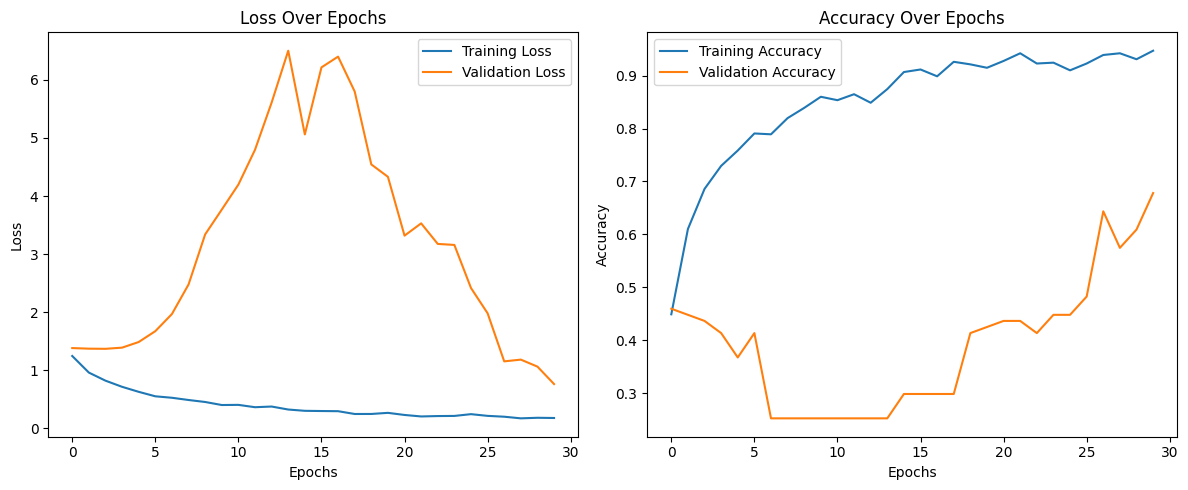

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 618ms/step

Performance on Test Data [Using Model_2-swish]
Precision: 0.8017396778654631
Recall: 0.7237569060773481
F1 Score: 0.6900443612190883
Accuracy: 0.7237569060773481
Confusion Matrix:
                      Acacia_Modesta  Albizia_Lebbeck  Bauhinia_Variegatav  \
Acacia_Modesta                   41                0                    0   
Albizia_Lebbeck                  26                9                    1   
Bauhinia_Variegatav               0                0                   41   
Unknown                           6                0                    2   

                     Unknown  
Acacia_Modesta             4  
Albizia_Lebbeck            7  
Bauhinia_Variegatav        4  
Unknown                   40  


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import random
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Add, GlobalAveragePooling2D, Flatten, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Directory for the dataset
data_dir = dataset

# Define the CNN architecture



# Define the CNN architecture
input_shape = (224, 224, 3)
num_classes = 4

# Input
inputs = layers.Input(shape=input_shape)

# LLF Net#1
a1 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(inputs)
a1 = layers.BatchNormalization()(a1)
a1 = layers.Activation('swish')(a1)
MPa1 = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(a1)

b1 = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same')(inputs)
b1 = layers.BatchNormalization()(b1)
b1 = layers.Activation('swish')(b1)
a1b1 = layers.Concatenate()([MPa1, b1])
a1b1 = layers.Conv2D(64, (1, 1), strides=(1, 1), padding='same')(a1b1)

a2 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(a1b1)
a2 = layers.BatchNormalization()(a2)
a2 = layers.Activation('swish')(a2)
MPa2 = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(a2)

b2 = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same')(a1b1)
b2 = layers.BatchNormalization()(b2)
b2 = layers.Activation('swish')(b2)

c1 = layers.Conv2D(32, (5, 5), strides=(4, 4), padding='same')(inputs)
c1 = layers.BatchNormalization()(c1)
c1 = layers.Activation('swish')(c1)
c1a2b2 = layers.Concatenate()([c1, MPa2, b2])

Net1 = layers.Conv2D(64, (1, 1), strides=(1, 1), padding='same')(c1a2b2)

BLock1 = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(Net1)
x=BLock1
# Block2 Inception
inception1_1 = Conv2D(128, (1, 1), activation='swish')(x)
inception1_3 = Conv2D(128, (1, 1), activation='swish')(x)
inception1_3 = Conv2D(192, (3, 3), activation='swish', padding='same')(inception1_3)
inception1_5 = Conv2D(32, (1, 1), activation='swish')(x)
inception1_5 = Conv2D(96, (5, 5), activation='swish', padding='same')(inception1_5)
inception1_7 = MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x)
inception1_7 = Conv2D(64, (1, 1), activation='swish')(inception1_7)
Incp2 = layers.Concatenate()([inception1_1, inception1_3, inception1_5, inception1_7])
Incp2  = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(Incp2)
x = Incp2
# Block3 Inception
inception1_1 = Conv2D(128, (1, 1), activation='swish')(x)
inception1_3 = Conv2D(128, (1, 1), activation='swish')(x)
inception1_3 = Conv2D(192, (3, 3), activation='swish', padding='same')(inception1_3)
inception1_5 = Conv2D(32, (1, 1), activation='swish')(x)
inception1_5 = Conv2D(96, (5, 5), activation='swish', padding='same')(inception1_5)
inception1_7 = MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x)
inception1_7 = Conv2D(64, (1, 1), activation='swish')(inception1_7)
Incp3 = layers.Concatenate()([inception1_1, inception1_3, inception1_5, inception1_7])
Incp3  = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(Incp3)
x = Incp3
# Global Average Pooling (GAP)
global_avg_pool = layers.GlobalAveragePooling2D()(x)
# Fully Connected Layer
outputs = layers.Dense(num_classes, activation='softmax')(global_avg_pool)

# Create the model
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Data generators for training, validation, and testing
train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'Train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(data_dir, 'Validate'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, 'Test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# Training the model
history = model.fit(train_generator, epochs=30, validation_data=val_generator)

# Plot training results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Helper function to evaluate the model on given test generator
def evaluate_model(test_generator, model, classes, title="Performance"):
    y_test_pred = model.predict(test_generator)
    y_test_pred = np.argmax(y_test_pred, axis=1)

    precision = precision_score(test_generator.labels, y_test_pred, average='weighted')
    recall = recall_score(test_generator.labels, y_test_pred, average='weighted')
    f1 = f1_score(test_generator.labels, y_test_pred, average='weighted')
    accuracy = accuracy_score(test_generator.labels, y_test_pred)

    print(f"\n{title}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Accuracy:", accuracy)

    # Display the confusion matrix
    confusion = confusion_matrix(test_generator.labels, y_test_pred)
    confusion_df = pd.DataFrame(confusion, index=classes, columns=classes)
    print("Confusion Matrix:\n", confusion_df)

# Test the model on the test set
evaluate_model(test_generator, model, ['Acacia_Modesta', 'Albizia_Lebbeck', 'Bauhinia_Variegatav', 'Unknown'], title="Performance on Test Data [Using Model_2-swish]")
